<a href="https://colab.research.google.com/github/crowell97/ES2245/blob/main/es2245_lecture19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lecture 19: Non-Parametric Statistics and Tests
**Course:** EARTHSC 2245 - Introductory Data Analysis for Earth and Environmental Sciences  
**Reference:** Chapter 18 and 19

This notebook explores the non-parametric statistical tests covered in Lecture 19. Parametric tests often rely on strict assumptions, such as normally distributed data and equal variances. When our data violates these assumptions (or when dealing with small sample sizes and ranked/ordinal data), we must fall back on non-parametric tests.

This notebook covers:
1. **Fisher Exact Test** (Small sample sizes, 2x2 contingency tables)
2. **McNemar Test** (Comparing related categorical samples)
3. **Kolmogorov-Smirnov (K-S) Test** (Comparing a single sample to an expected distribution)
4. **Mann-Whitney U Test** (Comparing two independent samples)
5. **Kruskal-Wallis Test** (Comparing more than two independent samples)
6. **Wilcoxon Signed-Rank Test** (Comparing two related/paired samples)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from statsmodels.stats.contingency_tables import mcnemar

# Set visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

## 1. The Fisher Exact Test
The Fisher Exact Test is used for 2x2 contingency tables, especially when sample sizes are small or expected frequencies are less than 5. It calculates the probability directly rather than using a test statistic to estimate it.

**Case Study: The K/T Extinction Boundary**
We are testing whether thick-shelled mollusks (an anti-predatory adaptation) were selected against across the Cretaceous/Tertiary (K/T) boundary. Out of 10 outcrops (5 above, 5 below), we look at the presence/absence of thick shells.

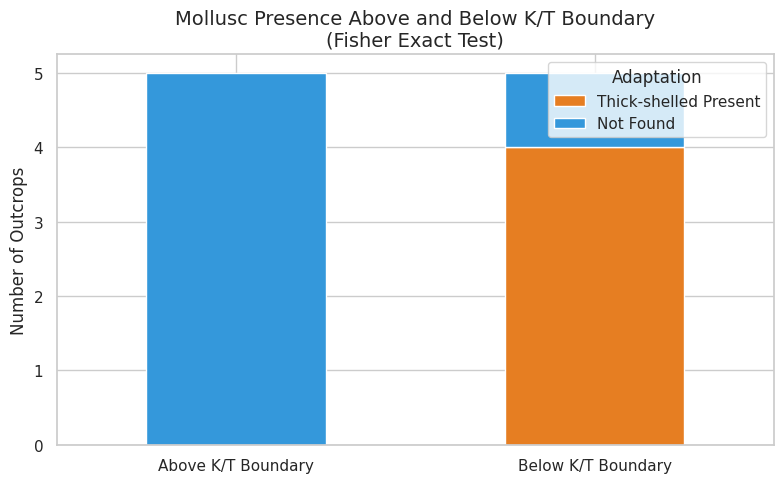

Fisher's Exact Test p-value: 0.0476
Conclusion: Significant difference in thick-shelled mollusc presence across the boundary.


In [2]:
# Data based on Table 18.4
# Rows: Above K/T, Below K/T
# Columns: Thick-shelled present, Thick-shelled not found
fisher_data = np.array([[0, 5],
                        [4, 1]])

# Perform Fisher's Exact Test
oddsratio, pvalue_fisher = stats.fisher_exact(fisher_data)

# Visualization
df_fisher = pd.DataFrame(fisher_data,
                         columns=['Thick-shelled Present', 'Not Found'],
                         index=['Above K/T Boundary', 'Below K/T Boundary'])

df_fisher.plot(kind='bar', stacked=True, color=['#e67e22', '#3498db'])
plt.title('Mollusc Presence Above and Below K/T Boundary\n(Fisher Exact Test)', fontsize=14)
plt.ylabel('Number of Outcrops')
plt.xticks(rotation=0)
plt.legend(title='Adaptation')
plt.tight_layout()
plt.show()

print(f"Fisher's Exact Test p-value: {pvalue_fisher:.4f}")
if pvalue_fisher < 0.05:
    print("Conclusion: Significant difference in thick-shelled mollusc presence across the boundary.")
else:
    print("Conclusion: No significant difference observed.")

## 2. The McNemar Test
The McNemar test is used to analyze two related samples of nominal scale data in two categories. It focuses specifically on cases that *changed* status between two observation points.

**Case Study: Ocean Beaches**
12 ocean beaches were measured in two successive years to see if they were accreting or eroding sand after jetties were constructed nearby.

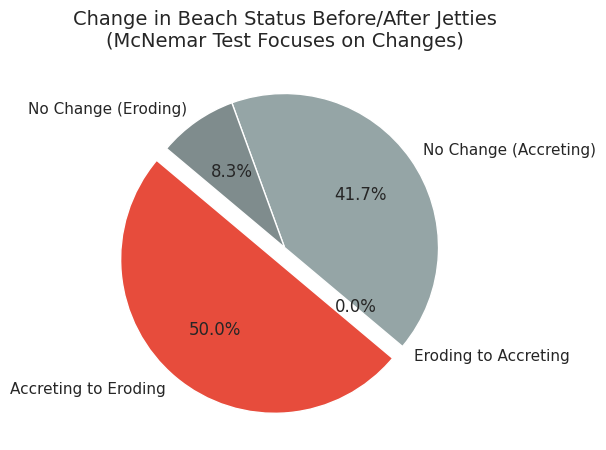

McNemar Test p-value: 0.0312


In [3]:
# Data based on Table 18.9
# 5 beaches kept accreting, 6 changed from accreting to eroding
# 0 changed from eroding to accreting, 1 kept eroding
# [[Accreting->Accreting (a), Accreting->Eroding (b)],
#  [Eroding->Accreting (c), Eroding->Eroding (d)]]
mcnemar_data = [[5, 6],
                [0, 1]]

# Perform McNemar Test (exact binominal due to small sample)
result_mcnemar = mcnemar(mcnemar_data, exact=True)

# Visualization
labels = ['Accreting to Eroding', 'Eroding to Accreting', 'No Change (Accreting)', 'No Change (Eroding)']
sizes = [6, 0, 5, 1]
colors = ['#e74c3c', '#2ecc71', '#95a5a6', '#7f8c8d']

plt.pie(sizes, labels=labels, autopct='%1.1f%%', colors=colors, startangle=140, explode=(0.1, 0, 0, 0))
plt.title('Change in Beach Status Before/After Jetties\n(McNemar Test Focuses on Changes)', fontsize=14)
plt.show()

print(f"McNemar Test p-value: {result_mcnemar.pvalue:.4f}")

## 3. Kolmogorov-Smirnov (K-S) Test
The K-S test determines if a single sample comes from a population with a specific, expected cumulative distribution. The test statistic ($D$) is the maximum absolute difference between the observed and expected cumulative proportions.

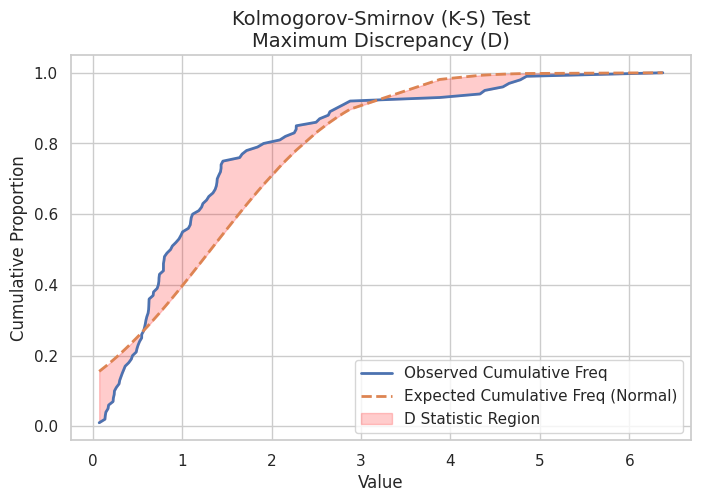

K-S Test D-statistic: 0.5445
K-S Test p-value: 0.000000


In [4]:
# Generate some skewed sample data
np.random.seed(42)
sample_data = np.random.lognormal(mean=0, sigma=1, size=100)

# We expect a normal distribution, but we feed it lognormal data
# The K-S test compares our sample against a standard normal distribution
d_stat, pvalue_ks = stats.kstest(sample_data, 'norm')

# Visualization: ECDF vs Theoretical CDF
x = np.sort(sample_data)
y_observed = np.arange(1, len(x)+1) / len(x)
y_expected = stats.norm.cdf(x, loc=np.mean(sample_data), scale=np.std(sample_data))

plt.plot(x, y_observed, label='Observed Cumulative Freq', linewidth=2)
plt.plot(x, y_expected, label='Expected Cumulative Freq (Normal)', linestyle='--', linewidth=2)
plt.fill_between(x, y_observed, y_expected, color='red', alpha=0.2, label='D Statistic Region')

plt.title('Kolmogorov-Smirnov (K-S) Test\nMaximum Discrepancy (D)', fontsize=14)
plt.xlabel('Value')
plt.ylabel('Cumulative Proportion')
plt.legend()
plt.show()

print(f"K-S Test D-statistic: {d_stat:.4f}")
print(f"K-S Test p-value: {pvalue_ks:.6f}")

## 4. The Mann-Whitney U Test
The Mann-Whitney U test (Wilcoxon rank-sum test) compares the distributions of two *independent* groups. It completely ignores raw numerical values and analyzes their combined ranks. It serves as the non-parametric equivalent of the independent t-test.

**Case Study: Clam Lengths**
Comparing the lengths of clams collected from two different, independent outcrops.

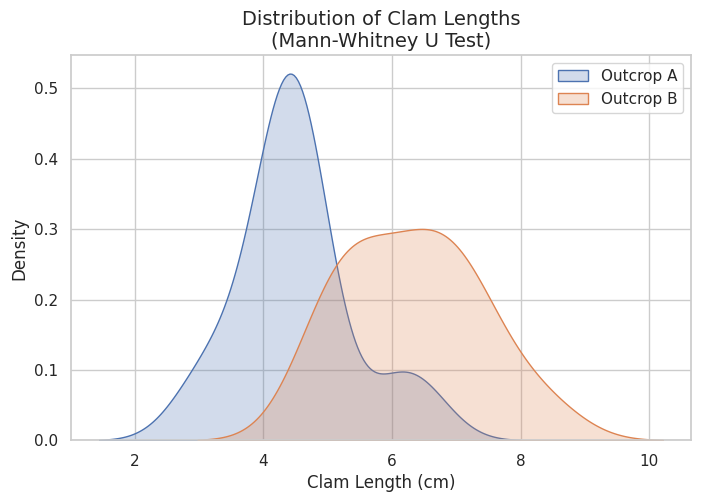

Mann-Whitney U statistic: 15.0000
Mann-Whitney U p-value: 0.0001


In [5]:
# Simulated Clam Lengths (cm)
outcrop_A = np.random.normal(loc=4.5, scale=0.8, size=15)
outcrop_B = np.random.normal(loc=6.2, scale=1.0, size=15)

# Perform Mann-Whitney U Test
u_stat, pvalue_mw = stats.mannwhitneyu(outcrop_A, outcrop_B, alternative='two-sided')

# Visualization
sns.kdeplot(outcrop_A, fill=True, label='Outcrop A')
sns.kdeplot(outcrop_B, fill=True, label='Outcrop B')
plt.title('Distribution of Clam Lengths\n(Mann-Whitney U Test)', fontsize=14)
plt.xlabel('Clam Length (cm)')
plt.ylabel('Density')
plt.legend()
plt.show()

print(f"Mann-Whitney U statistic: {u_stat:.4f}")
print(f"Mann-Whitney U p-value: {pvalue_mw:.4f}")

## 5. The Kruskal-Wallis Test
The Kruskal-Wallis test is the non-parametric equivalent to a one-way ANOVA. It compares the median ranks across *three or more* independent samples to see if they differ significantly.

/tmp/ipykernel_2011/2236184926.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='River', y='Concentration', data=df_kw, palette='Set2')


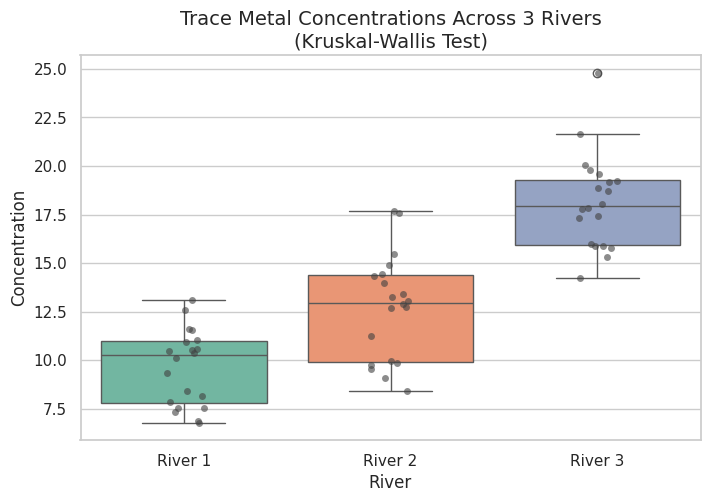

Kruskal-Wallis H-statistic: 41.1649
Kruskal-Wallis p-value: 0.000000


In [6]:
# Simulated data: Trace metal concentrations from 3 different river branches
river_1 = np.random.normal(loc=10, scale=2, size=20)
river_2 = np.random.normal(loc=12, scale=3, size=20)
river_3 = np.random.normal(loc=18, scale=2.5, size=20) # Significantly higher

# Perform Kruskal-Wallis Test
h_stat, pvalue_kw = stats.kruskal(river_1, river_2, river_3)

# Visualization
df_kw = pd.DataFrame({'Concentration': np.concatenate([river_1, river_2, river_3]),
                      'River': ['River 1']*20 + ['River 2']*20 + ['River 3']*20})

sns.boxplot(x='River', y='Concentration', data=df_kw, palette='Set2')
sns.stripplot(x='River', y='Concentration', data=df_kw, color=".25", alpha=0.6)
plt.title('Trace Metal Concentrations Across 3 Rivers\n(Kruskal-Wallis Test)', fontsize=14)
plt.show()

print(f"Kruskal-Wallis H-statistic: {h_stat:.4f}")
print(f"Kruskal-Wallis p-value: {pvalue_kw:.6f}")

## 6. The Wilcoxon Signed-Rank Test
This test is used for non-parametric comparisons between two *related* (paired) samples. It ranks the absolute *differences* between the paired measurements, re-assigns the positive/negative signs, and sums the ranks.

**Case Study: Asbestos Lesions**
Testing if inhaled asbestos fibers result in a higher incidence of lesions in the right lung compared to the left lung of the exact same 10 individuals.

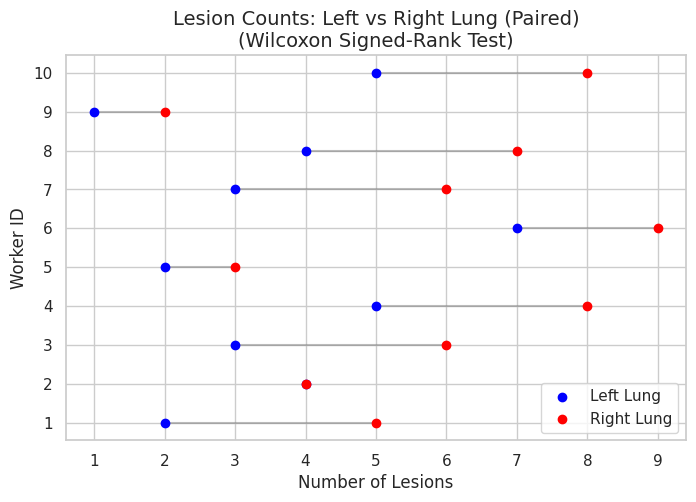

Wilcoxon Signed-Rank W-statistic: 0.0000
Wilcoxon Signed-Rank p-value: 0.0039


In [7]:
# Simulated Lesion Counts for 10 workers (Right Lung tends to have more)
worker_id = np.arange(1, 11)
left_lung = np.array([2, 4, 3, 5, 2, 7, 3, 4, 1, 5])
right_lung = np.array([5, 4, 6, 8, 3, 9, 6, 7, 2, 8])

# Perform Wilcoxon Signed-Rank Test
w_stat, pvalue_wilcoxon = stats.wilcoxon(left_lung, right_lung)

# Visualization (Dumbbell Plot to show paired differences)
plt.hlines(y=worker_id, xmin=left_lung, xmax=right_lung, color='grey', alpha=0.5)
plt.scatter(left_lung, worker_id, color='blue', alpha=1, label='Left Lung', zorder=3)
plt.scatter(right_lung, worker_id, color='red', alpha=1, label='Right Lung', zorder=3)

plt.title('Lesion Counts: Left vs Right Lung (Paired)\n(Wilcoxon Signed-Rank Test)', fontsize=14)
plt.xlabel('Number of Lesions')
plt.ylabel('Worker ID')
plt.yticks(worker_id)
plt.legend()
plt.show()

print(f"Wilcoxon Signed-Rank W-statistic: {w_stat:.4f}")
print(f"Wilcoxon Signed-Rank p-value: {pvalue_wilcoxon:.4f}")